In [ ]:
import os 
import pandas as pd
from functools import reduce
import pandas as pd 
import seaborn as sns
import matplotlib.pyplot as plt
from typing import Tuple
import numpy as np

# Utils 
def process_objects(objects, top_n):
    objects = objects.loc[:,~objects.columns.isin(["bottle","glass, drinking glass","box","door","grass","wall", "floor", "ceiling", 
                                                "column", "person", "rail", "column, pillar", "step, stair", "food, solid food",
                                                'building', 'sky', 'tree', 'road, route','sidewalk, pavement', 'earth, ground',
                                                'mountain, mount', 'car', 'pier'])]


    
    objects["room_type"] = [i.split("__")[0] for i in objects.image]

    top_objects = list(set(
        objects.drop(["image"], axis = 1).groupby("room_type").sum()
        .stack()
        .groupby(level=0, group_keys=False)
        .apply(lambda x: x.nlargest(top_n))
        .index.get_level_values(1)  # Extracts feature names
    ))
    top_objects.append("image")


    objects = objects[objects.columns.intersection(top_objects)]
    return objects
    #objects.drop(columns = ['pillow', 'computer', "sink"], inplace=True)

def correlation_plot(data: pd.DataFrame, plot_size: Tuple[int,int] = (20,10), annot: bool = True, annot_size: int = 6, filter_cor: bool = True, filter_value: int = 0.8) -> None:
    numeric_cols = data.select_dtypes(include="number").columns
    data = data[numeric_cols]
    correlation_matrix = data.corr()

    
    upper = correlation_matrix.where(
        np.triu(np.ones(correlation_matrix.shape), k=1).astype(bool)
    )

    high_corr = upper.stack().reset_index()
    high_corr.columns = ["Feature 1", "Feature 2", "Correlation"]

    high_corr = high_corr[
        (high_corr["Correlation"] > filter_value) |
        (high_corr["Correlation"] < -filter_value)
    ]

    print(high_corr)


    if filter_cor:
        correlation_matrix = correlation_matrix.where((correlation_matrix > filter_value) | (correlation_matrix < -filter_value))

    plt.subplots(figsize=plot_size)
    sns.heatmap(
        correlation_matrix, 
        annot=annot, 
        annot_kws={'size': annot_size},  # Reduce font size
        vmin=-1, vmax=1, 
    #    cmap='coolwarm'
    )
    plt.show()

def order_filter_dataframe(data, low_level_features, mid_level_features, high_level_features, image_column_name):
    
    low = [col for col in low_level_features if col != image_column_name]
    mid = [col for col in mid_level_features if col != image_column_name]
    high = [col for col in high_level_features if col != image_column_name]

    ordered_features = [image_column_name] + low + mid + high

    # Keep only columns that exist
    ordered_features = [col for col in ordered_features if col in data.columns]

    # Apply ordering
    data = data[ordered_features]
    
    return data

data_loc = r"C:\Users\20225378\Desktop\Extract Visual Features\Extracted Visual Features"

all_visual_features = []
low_level_features = set()
mid_level_features = set()
high_level_features = set()
for folder in os.listdir(data_loc):
    if os.path.isdir(folder) and folder != "Combined":
        sub_folder = os.path.join(data_loc, folder)
        for csv_file in os.listdir(sub_folder):
            if csv_file.lower().endswith(".csv"):
                data = pd.read_csv(os.path.join(sub_folder, csv_file))

                if csv_file == "low_level_features.csv":
                    low_level_features.update(list(data.columns))

                elif csv_file == "functions.csv":
                    data = data[['image',"reading", "eating", "gaming", "conducting business", "studying", "socializing", "cleaning", "playing", "training", 
                       "exercise", "research", "congregating", "competing", "working", "waiting in line", "using tools", "shopping"]]
                    high_level_features.update(list(data.columns))
                    
                elif csv_file == "contour.csv":
                    data = data[["orientation5", "length7", "curvature7", "image"]]
                    mid_level_features.update(list(data.columns))

                elif csv_file == "objects.csv":
                    data = process_objects(data, top_n = 5)
                    mid_level_features.update(list(data.columns))

                else:
                    mid_level_features.update(list(data.columns))

                all_visual_features.append(data)

data = reduce(lambda left, right: pd.merge(left, right, on="image", how="outer"),all_visual_features)


C:\Users\20225378\AppData\Local\Temp\ipykernel_26984\1333334826.py:19: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  objects["room_type"] = [i.split("__")[0] for i in objects.image]


         Feature 1        Feature 2  Correlation
15  first_order_ed  second_order_ed     0.907218
26          mean_b        fractal_D     0.856007


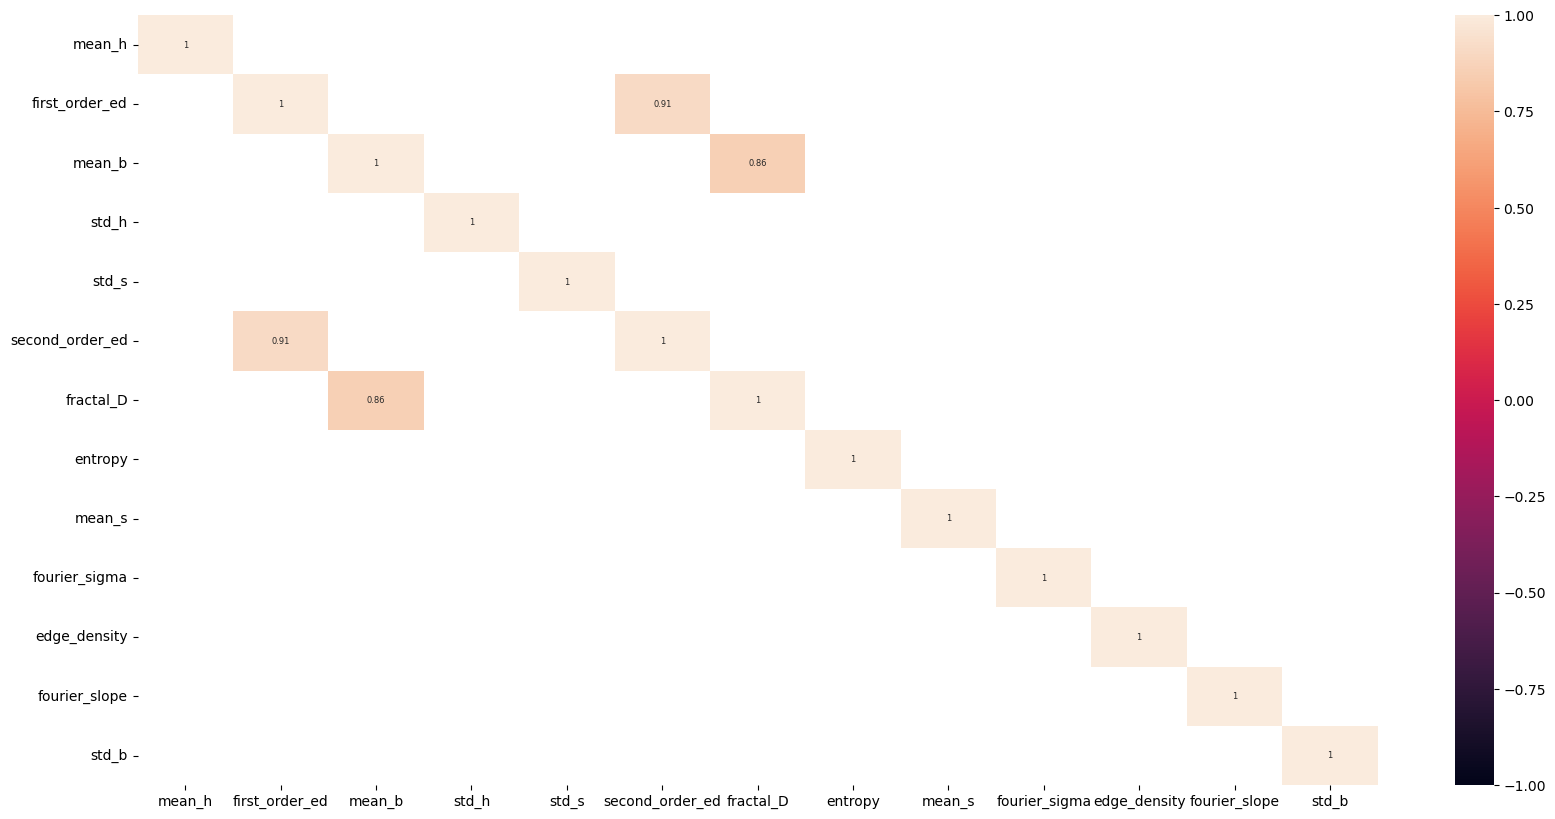

Empty DataFrame
Columns: [Feature 1, Feature 2, Correlation]
Index: []


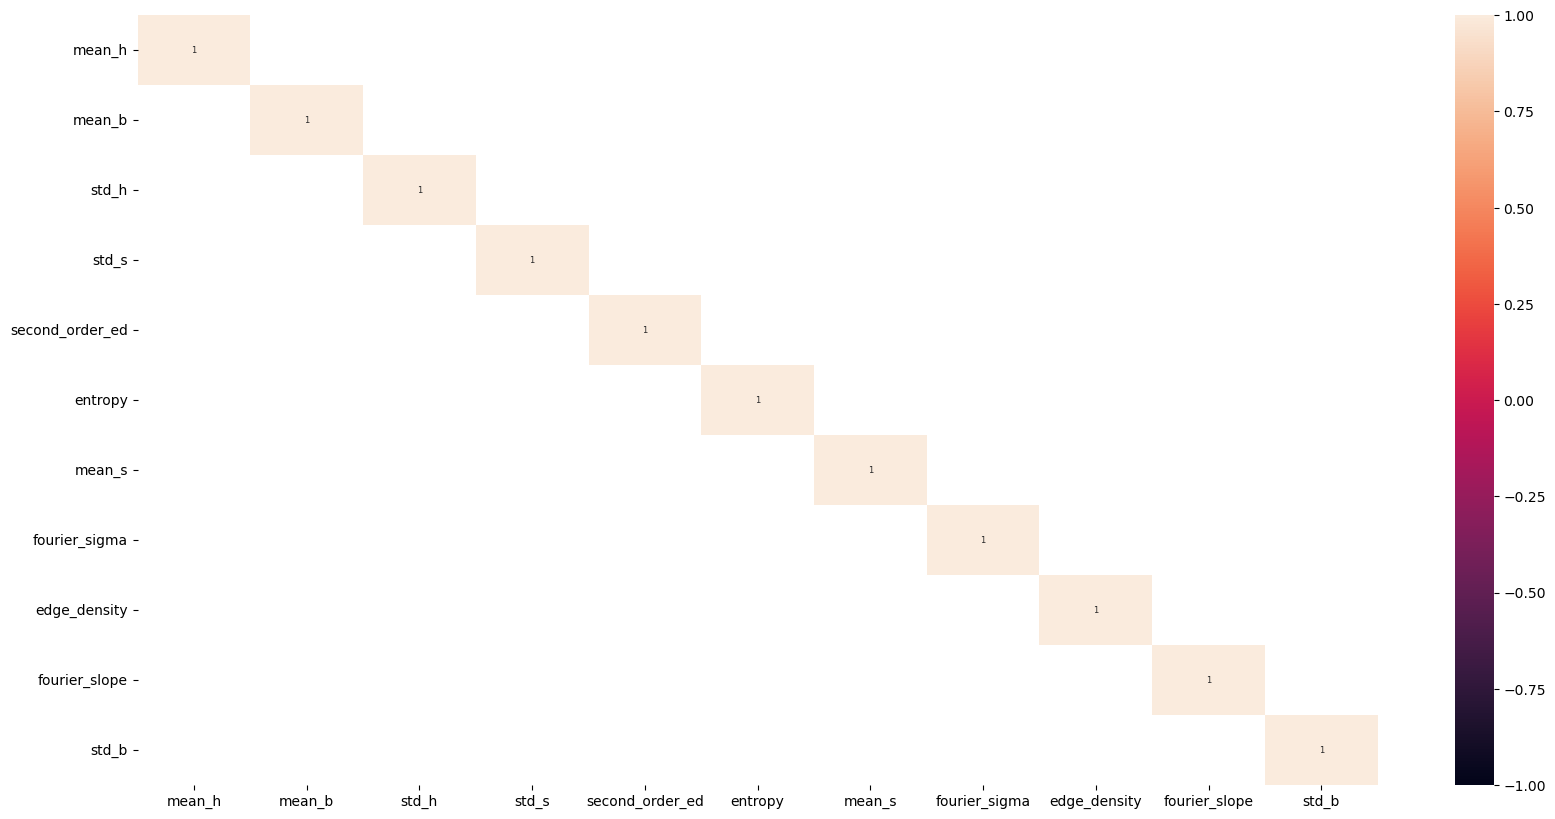

In [19]:
correlation_plot(data[list(low_level_features)], (20,10), annot_size = 6, filter_cor = True, filter_value=0.8)
low_level_features = low_level_features.difference(["fractal_D", "first_order_ed"])
correlation_plot(data[list(low_level_features)], (20,10), annot_size = 6, filter_cor = True, filter_value=0.8)



            Feature 1    Feature 2  Correlation
38   far-away horizon   no horizon    -0.807182
239    symmetry_lr_ud  symmetry_ud     0.864472
285            pillow          bed     0.811602


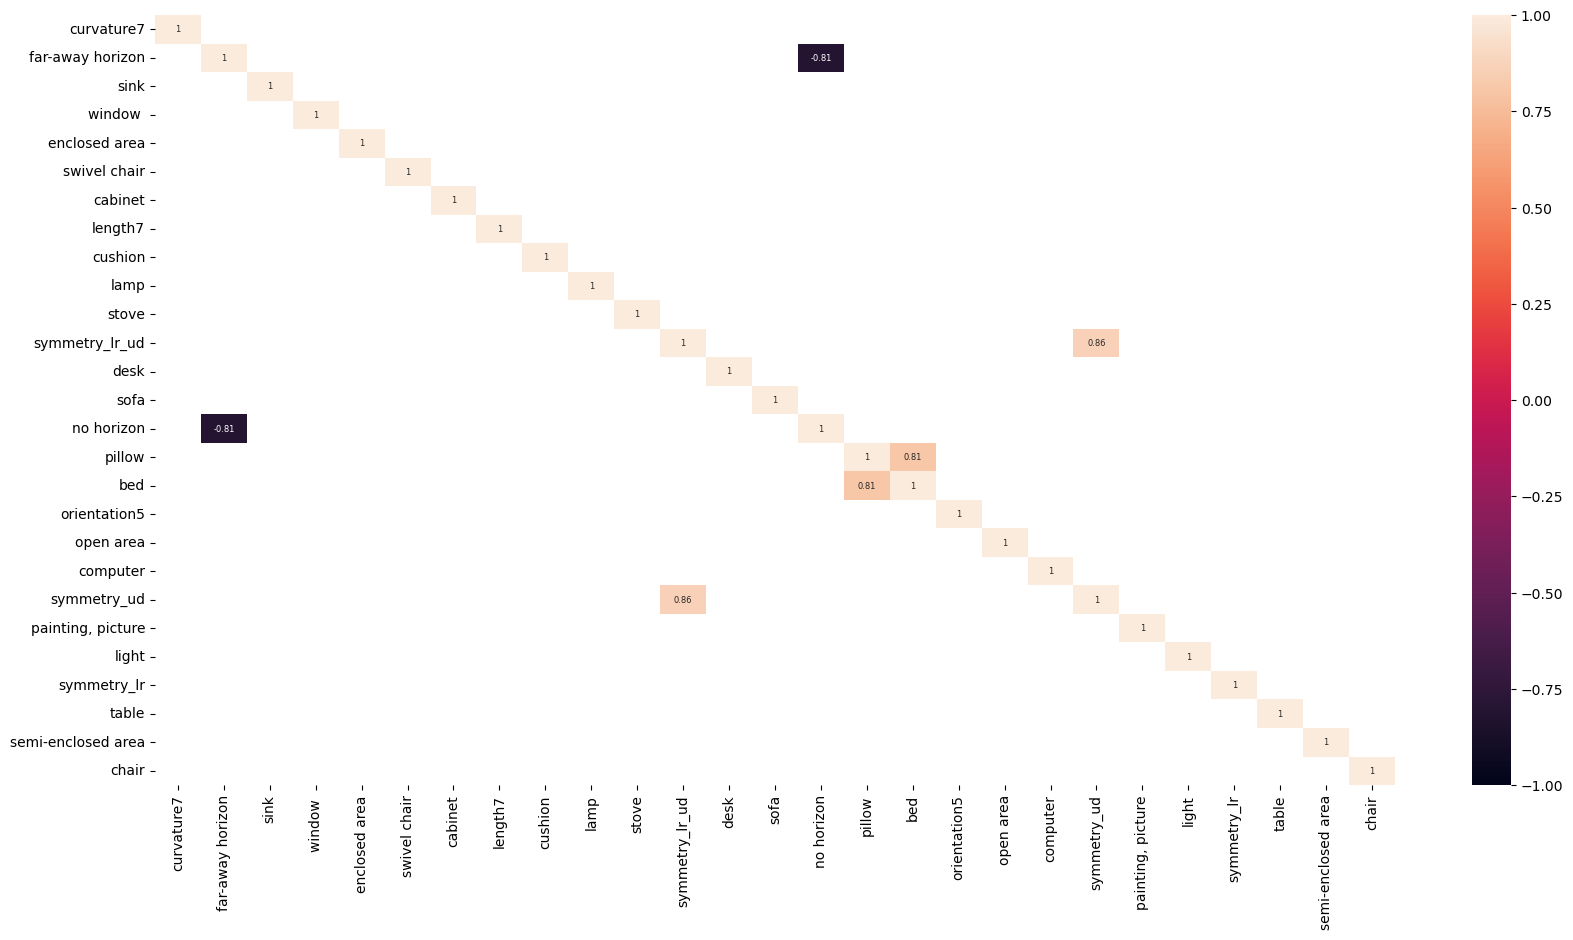

Empty DataFrame
Columns: [Feature 1, Feature 2, Correlation]
Index: []


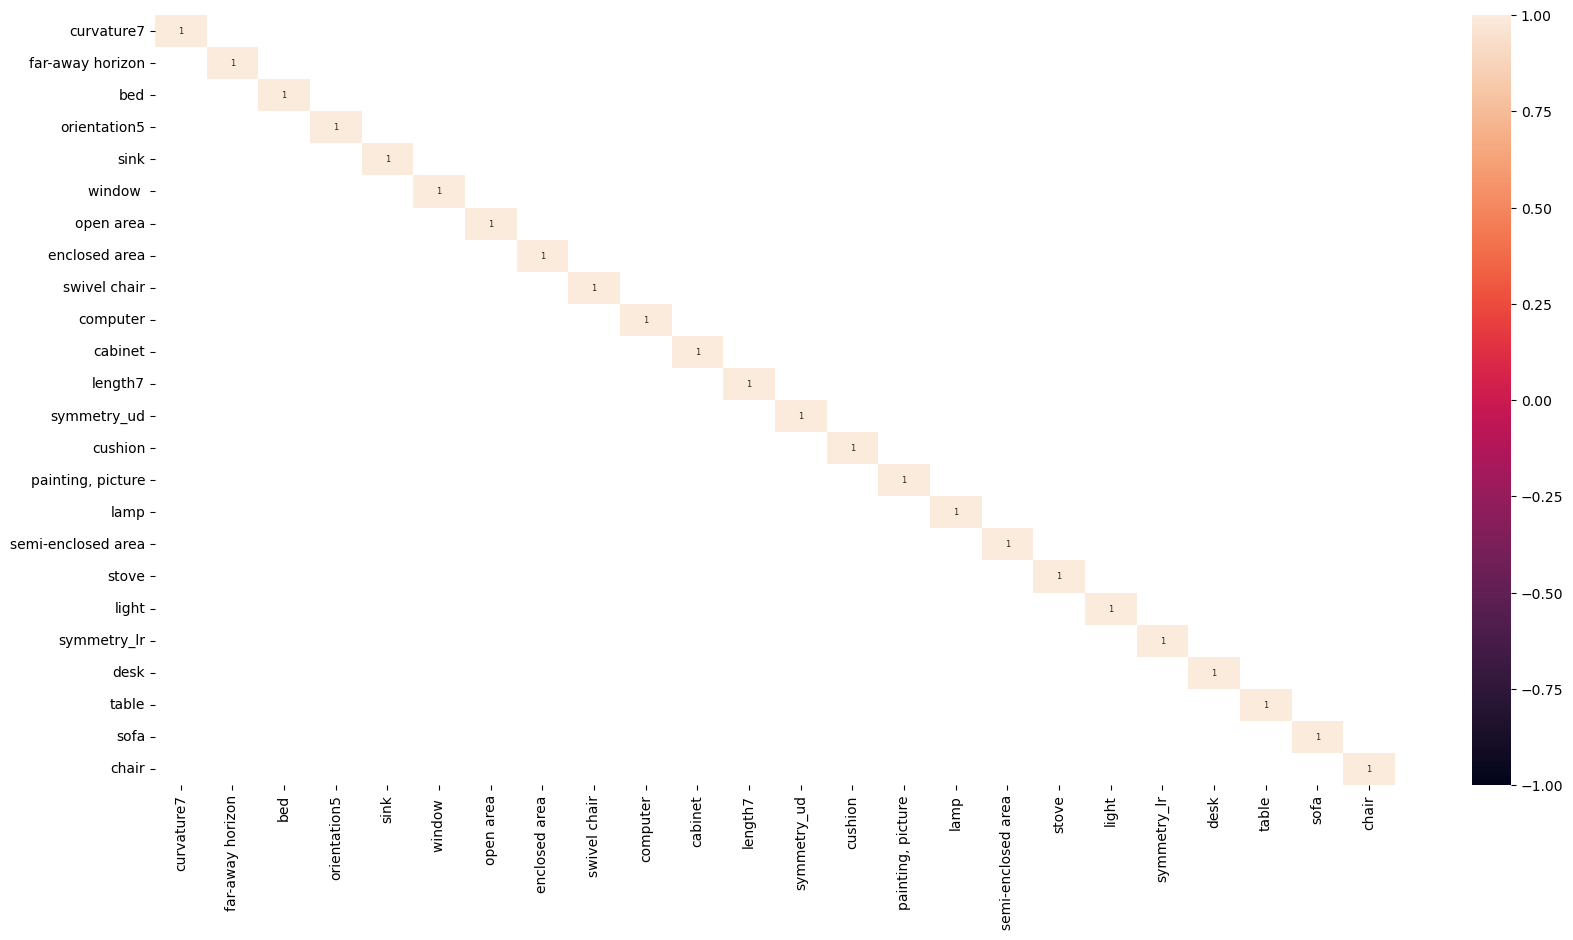

In [20]:
correlation_plot(data[list(mid_level_features)], (20,10), annot_size = 6, filter_cor = True, filter_value=0.8)
mid_level_features = mid_level_features.difference(["symmetry_lr_ud", "pillow", "no horizon"])
correlation_plot(data[list(mid_level_features)], (20,10), annot_size = 6, filter_cor = True, filter_value=0.8)


               Feature 1            Feature 2  Correlation
2                 eating          socializing     0.899887
39              exercise            competing     0.880026
45           socializing         congregating     0.928409
81              training  conducting business     0.900840
86              training             research     0.841503
87              training             studying     0.954134
93   conducting business              working     0.874252
95   conducting business             research     0.894445
96   conducting business             studying     0.934532
106      waiting in line             shopping     0.800985
116              working             research     0.947824
117              working             studying     0.824949
126             research             studying     0.907429


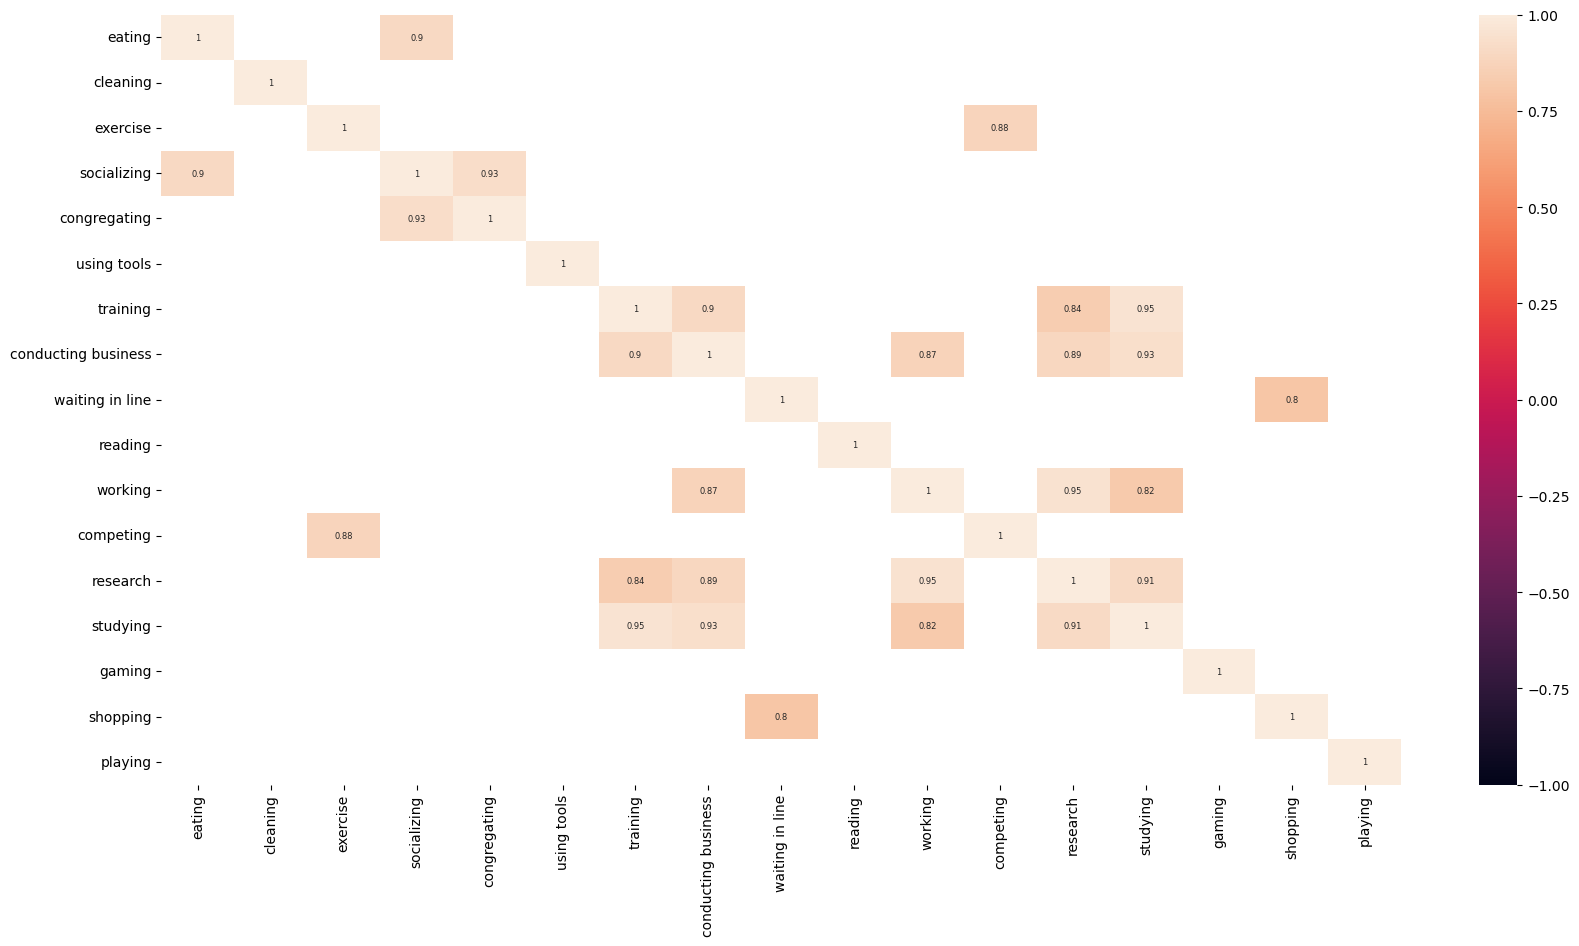

Empty DataFrame
Columns: [Feature 1, Feature 2, Correlation]
Index: []


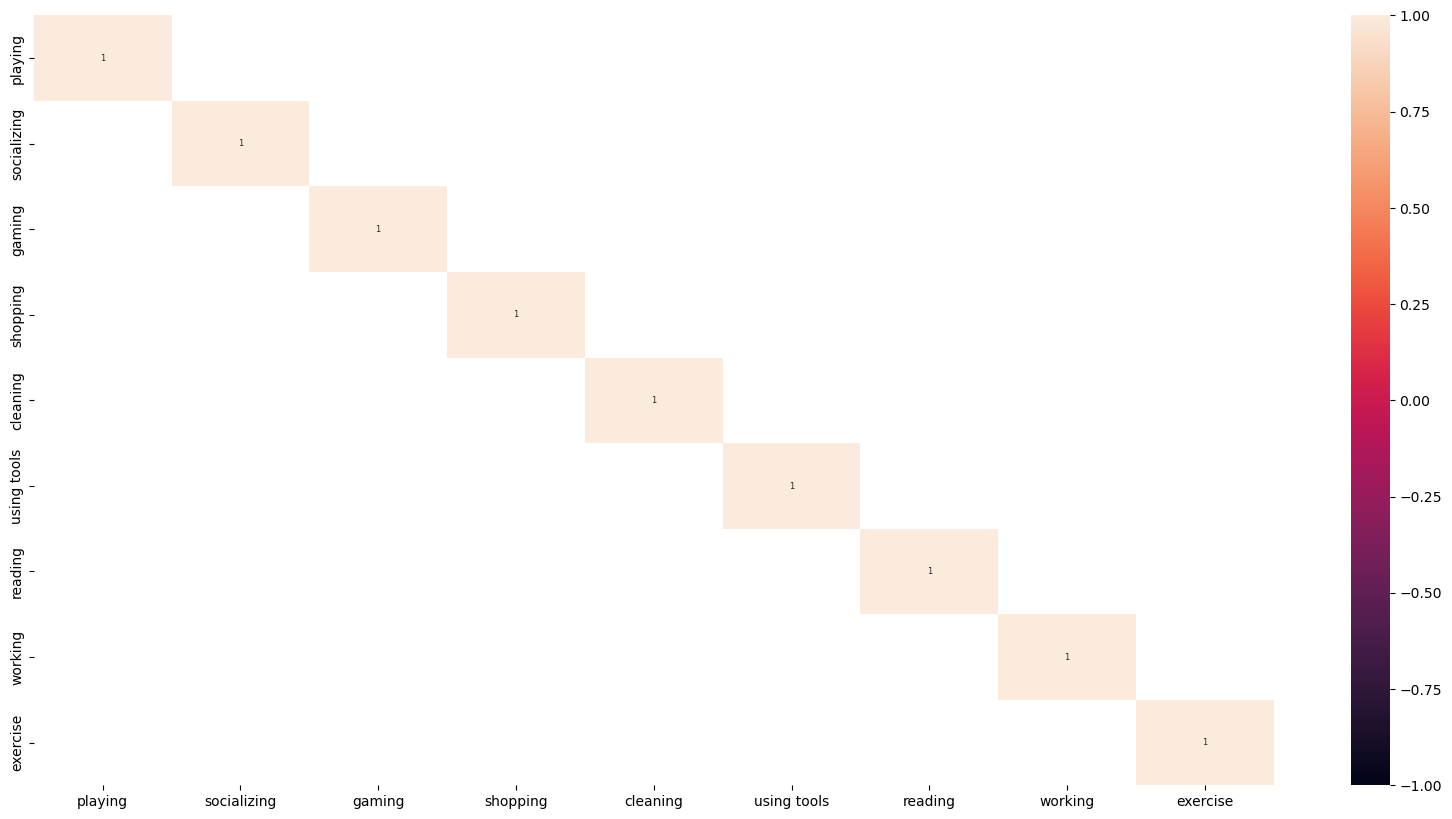

In [21]:
correlation_plot(data[list(high_level_features)], (20,10), annot_size = 6, filter_cor = True, filter_value=0.8)
high_level_features = high_level_features.difference(["eating", "studying","training", "research", "conducting business", "congregating", "competing", "waiting in line"])
correlation_plot(data[list(high_level_features)], (20,10), annot_size = 6, filter_cor = True, filter_value=0.8)


Empty DataFrame
Columns: [Feature 1, Feature 2, Correlation]
Index: []


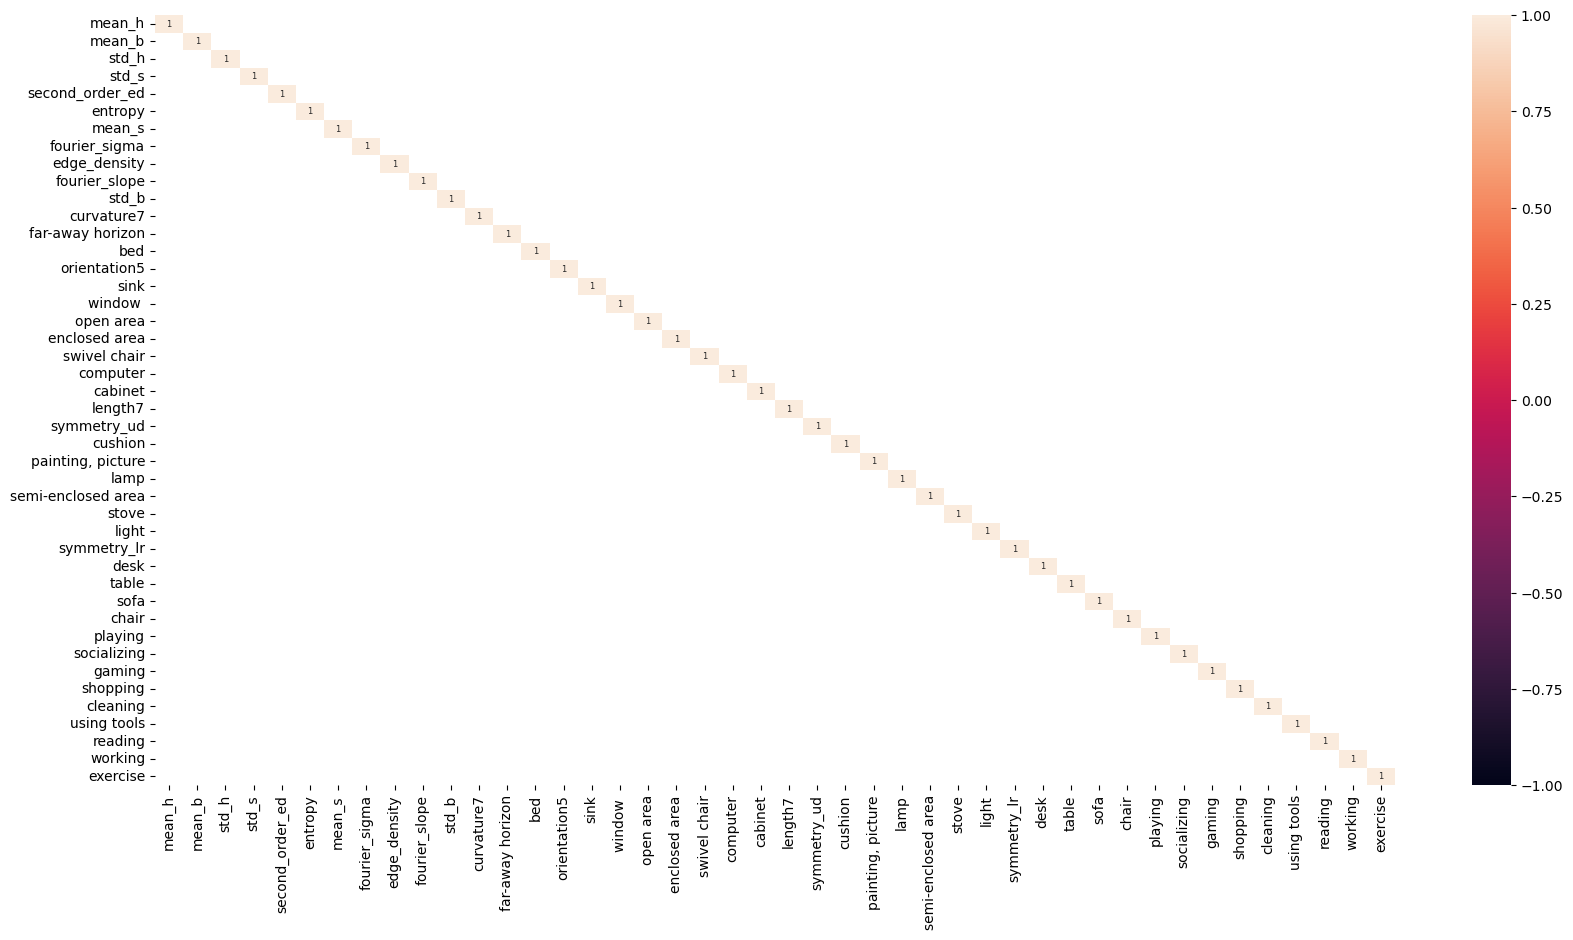

In [ ]:
data = order_filter_dataframe(data, low_level_features, mid_level_features, high_level_features, "image")
correlation_plot(data, (20,10), annot_size = 6, filter_cor = True, filter_value=0.8)

In [44]:
affect_data = pd.read_csv(r"C:\Users\20225378\Desktop\IDEAS final\Mean Data\combined_data.csv")[["image", "valence", "approach", "tense", "energetic"]]
pd.merge(data, affect_data, on = 'image').to_csv(r"./Combined/combined_visual_features.csv", index = False)